<a href="https://colab.research.google.com/github/NSF-DARSE/YolktoFeed/blob/main/JupyterNotebook/liverHEDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Checks to the implemented
- Test is the all values from column 1 df.iloc[:,1:] to the right is numbers
- Test if column name follows the same pattern
- While omitting based on average, see if any value has any spike on some days

In [6]:
import pandas as pd
import sys

In [12]:
#from google.colab import drive
#drive.mount("/content/drive/")

In [7]:
path = "/content/drive/Shareddrives/NSF-SCIPE-DARSE/Research Software Engineers (RSE)/Abhin/Projects/Carl Schmidt"
sys.path.append(path)

In [16]:
df_base = pd.read_csv(path+"/Liver_HEIDI_complete_ensembl_symbol.csv")

In [17]:
df_base.shape

(24869, 108)

In [18]:
# finding last row with valid gene symbol
gene_list_last_index = (df_base["Gene Symbol"] == "-").idxmax()

## Checking for nan

In [10]:
#from numpy import nan
#df.iloc[1,3:] = nan
#df.iloc[1,4:10] = nan

In [19]:
# index from 2 to exclude gene id and gene symbol
df_base.iloc[:,2:].apply(pd.to_numeric, errors='coerce').isna().sum().sum()

np.int64(0)

## Trucating till the valid gene name

In [20]:
#truncating till that row
df_trunk = df_base.iloc[:gene_list_last_index]
df_trunk = df_trunk.drop(columns=["Ensembl Gene ID"])
df_trunk

,Gene Symbol,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,1672_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
0,ZZZ3,2.148670,4.204060,3.609380,6.677230,3.849120,7.354150,5.040800,3.031530,2.721210,...,0.970587,1.66351,1.636580,2.459220,4.893390,2.489600,3.19717,1.468440,2.091560,0.187683
1,ZYX,24.366200,32.569200,31.253900,37.847200,37.692800,56.604800,33.385700,27.918300,34.052300,...,13.140900,24.40290,25.381200,28.666700,34.741500,22.507700,29.35630,25.152600,34.865400,12.079700
2,ZXDC,2.032480,2.471470,1.543100,3.037720,1.771860,4.079810,2.900180,2.161720,2.230180,...,0.945374,1.22140,1.271560,2.263090,2.274030,1.651320,2.59244,2.715000,2.818080,0.710741
3,ZW10,4.834760,7.150830,5.563670,10.117100,5.905610,12.052000,9.869820,6.426870,5.543910,...,2.026740,3.13406,4.484710,5.776710,8.311750,4.391920,6.41727,4.316070,5.518810,1.944010
4,ZUFSP,3.170700,2.908370,2.354820,3.346660,2.564770,3.133150,4.454180,3.496990,2.421560,...,2.675900,1.74104,1.222440,3.358820,3.351070,2.998520,2.41147,1.658470,2.003540,0.645755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14460,A4GALT,0.074452,0.156464,0.029587,0.139465,0.190539,0.308782,0.056601,0.067055,0.061017,...,0.172556,0.00000,0.131267,0.230045,0.594857,0.254973,0.22188,0.201177,0.596807,0.095215
14461,A2ML4,243.909000,340.262000,289.809000,584.728000,281.682000,509.980000,664.186000,492.456000,1092.230000,...,211.638000,641.81200,604.835000,1026.430000,1004.110000,480.376000,1000.24000,778.891000,1191.370000,394.840000
14462,A2ML2,247.332000,182.951000,172.501000,183.129000,118.826000,234.194000,283.293000,169.966000,165.030000,...,130.653000,193.07000,301.891000,275.247000,395.356000,316.083000,156.38600,128.938000,186.548000,81.135700
14463,A1CF,22.040600,55.038200,26.661900,96.158400,26.078800,69.539400,111.482000,104.168000,76.200500,...,15.616700,37.06100,14.489100,36.690700,35.393500,20.619700,48.11020,28.213400,27.961700,4.667240


## Adding a column for average and variance value of gene expression

In [21]:
# Adding a column for average gene expression across all days and all chikens for prelim analysis
df_trunk.insert(1, "avg", df_trunk.iloc[:, 1:].sum(axis=1)/(df_trunk.shape[1]-1))
df_trunk.insert(2, "sigma", df_trunk.iloc[:,1:].var(axis=1))
df_trunk.insert(3, "max", df_trunk.iloc[:,1:].max(axis=1))

In [22]:
df_trunk

,Gene Symbol,avg,sigma,max,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
0,ZZZ3,3.622199,4.078277,10.133400,2.148670,4.204060,3.609380,6.677230,3.849120,7.354150,...,0.970587,1.66351,1.636580,2.459220,4.893390,2.489600,3.19717,1.468440,2.091560,0.187683
1,ZYX,28.979918,92.037086,92.037086,24.366200,32.569200,31.253900,37.847200,37.692800,56.604800,...,13.140900,24.40290,25.381200,28.666700,34.741500,22.507700,29.35630,25.152600,34.865400,12.079700
2,ZXDC,2.306640,1.159855,5.924810,2.032480,2.471470,1.543100,3.037720,1.771860,4.079810,...,0.945374,1.22140,1.271560,2.263090,2.274030,1.651320,2.59244,2.715000,2.818080,0.710741
3,ZW10,6.449800,8.820332,14.179500,4.834760,7.150830,5.563670,10.117100,5.905610,12.052000,...,2.026740,3.13406,4.484710,5.776710,8.311750,4.391920,6.41727,4.316070,5.518810,1.944010
4,ZUFSP,3.944223,5.608118,12.019500,3.170700,2.908370,2.354820,3.346660,2.564770,3.133150,...,2.675900,1.74104,1.222440,3.358820,3.351070,2.998520,2.41147,1.658470,2.003540,0.645755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14460,A4GALT,0.295477,0.036620,0.882417,0.074452,0.156464,0.029587,0.139465,0.190539,0.308782,...,0.172556,0.00000,0.131267,0.230045,0.594857,0.254973,0.22188,0.201177,0.596807,0.095215
14461,A2ML4,663.624438,150677.470732,150677.470732,243.909000,340.262000,289.809000,584.728000,281.682000,509.980000,...,211.638000,641.81200,604.835000,1026.430000,1004.110000,480.376000,1000.24000,778.891000,1191.370000,394.840000
14462,A2ML2,210.725798,8557.568605,8557.568605,247.332000,182.951000,172.501000,183.129000,118.826000,234.194000,...,130.653000,193.07000,301.891000,275.247000,395.356000,316.083000,156.38600,128.938000,186.548000,81.135700
14463,A1CF,52.387588,1164.264418,1164.264418,22.040600,55.038200,26.661900,96.158400,26.078800,69.539400,...,15.616700,37.06100,14.489100,36.690700,35.393500,20.619700,48.11020,28.213400,27.961700,4.667240


## Part before omission of valid rows

In [47]:
df = df_trunk

In [48]:
#Basic stats on average gene expression levels with their corresponding sigma
#column 1 is avg, 2 is sigma, 3 is max
print("number of Genes and max variance less than 1e-6 and its max sigma/val:\t", df.loc[df.iloc[:,1] < 1e-6, df.columns[0:2]].shape[0], "\t",  df.loc[df.iloc[:,1] < 1e-6, df.columns[2]].max(), "\t", df.loc[df.iloc[:,1] < 1e-6, df.columns[3]].max())
print("number of Genes and max variance less than 1e-4 and its max sigma/val:\t", df.loc[df.iloc[:,1] < 1e-4, df.columns[0:2]].shape[0], "\t",  df.loc[df.iloc[:,1] < 1e-4, df.columns[2]].max(), "\t", df.loc[df.iloc[:,1] < 1e-4, df.columns[3]].max())
print("number of Genes and max variance less than 1e-2 and its max sigma/val:\t", df.loc[df.iloc[:,1] < 1e-2, df.columns[0:2]].shape[0], "\t",  df.loc[df.iloc[:,1] < 1e-2, df.columns[2]].max(), "\t", df.loc[df.iloc[:,1] < 1e-2, df.columns[3]].max())
print("number of Genes and max variance less than 1e-1 and its max sigma/val:\t", df.loc[df.iloc[:,1] < 1e-1, df.columns[0:2]].shape[0], "\t",  df.loc[df.iloc[:,1] < 1e-1, df.columns[2]].max(), "\t", df.loc[df.iloc[:,1] < 1e-1, df.columns[3]].max())

number of Genes and max variance less than 1e-6 and its max sigma/val:	 856 	 0.0 	 0.0
number of Genes and max variance less than 1e-4 and its max sigma/val:	 861 	 1.0162009896760454e-06 	 0.010428
number of Genes and max variance less than 1e-2 and its max sigma/val:	 2014 	 0.007519074558599177 	 0.897002
number of Genes and max variance less than 1e-1 and its max sigma/val:	 3230 	 0.425126707757173 	 6.5941


In [49]:
df.loc[(df.loc[:,'avg'] < 1e-1) & (df.loc[:,'max'] > 1), df.columns[:4]]
#df.loc[df.iloc[:,1] < 1e-2, df.columns[0:2]]
# Printing some Values in between 1e-6 and 1e-4
#df.loc[(df.iloc[:,1] > 1e-6) & (df.iloc[:,1] < 1e-4), df.columns[0:3]]
#df.iloc[353,0:2]

,Gene Symbol,avg,sigma,max
150,ZFRL1,0.037958,0.041971,1.45680
364,WNT16,0.091245,0.081054,2.57863
973,TRPM5,0.072176,0.068681,2.48666
1052,TRH,0.042037,0.037910,1.98859
1187,TNNC2,0.069872,0.090859,2.45912
...,...,...,...,...
13765,ARHGAP44,0.087614,0.019456,1.00127
13810,AQP7,0.065446,0.065920,1.81045
14136,AGPAT1,0.023302,0.057011,2.46996
14300,ACTC1,0.082108,0.090811,2.22788


## Keeping genes with avg > 0.1 or max > 1

In [50]:
#df = df[(df.loc[:,'avg'] > 1e-1)]
df = df[(df.loc[:,'avg'] > 1e-1) | (df.loc[:,'max'] > 1)]
df

,Gene Symbol,avg,sigma,max,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
0,ZZZ3,3.622199,4.078277,10.133400,2.148670,4.204060,3.609380,6.677230,3.849120,7.354150,...,0.970587,1.66351,1.636580,2.459220,4.893390,2.489600,3.19717,1.468440,2.091560,0.187683
1,ZYX,28.979918,92.037086,92.037086,24.366200,32.569200,31.253900,37.847200,37.692800,56.604800,...,13.140900,24.40290,25.381200,28.666700,34.741500,22.507700,29.35630,25.152600,34.865400,12.079700
2,ZXDC,2.306640,1.159855,5.924810,2.032480,2.471470,1.543100,3.037720,1.771860,4.079810,...,0.945374,1.22140,1.271560,2.263090,2.274030,1.651320,2.59244,2.715000,2.818080,0.710741
3,ZW10,6.449800,8.820332,14.179500,4.834760,7.150830,5.563670,10.117100,5.905610,12.052000,...,2.026740,3.13406,4.484710,5.776710,8.311750,4.391920,6.41727,4.316070,5.518810,1.944010
4,ZUFSP,3.944223,5.608118,12.019500,3.170700,2.908370,2.354820,3.346660,2.564770,3.133150,...,2.675900,1.74104,1.222440,3.358820,3.351070,2.998520,2.41147,1.658470,2.003540,0.645755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14460,A4GALT,0.295477,0.036620,0.882417,0.074452,0.156464,0.029587,0.139465,0.190539,0.308782,...,0.172556,0.00000,0.131267,0.230045,0.594857,0.254973,0.22188,0.201177,0.596807,0.095215
14461,A2ML4,663.624438,150677.470732,150677.470732,243.909000,340.262000,289.809000,584.728000,281.682000,509.980000,...,211.638000,641.81200,604.835000,1026.430000,1004.110000,480.376000,1000.24000,778.891000,1191.370000,394.840000
14462,A2ML2,210.725798,8557.568605,8557.568605,247.332000,182.951000,172.501000,183.129000,118.826000,234.194000,...,130.653000,193.07000,301.891000,275.247000,395.356000,316.083000,156.38600,128.938000,186.548000,81.135700
14463,A1CF,52.387588,1164.264418,1164.264418,22.040600,55.038200,26.661900,96.158400,26.078800,69.539400,...,15.616700,37.06100,14.489100,36.690700,35.393500,20.619700,48.11020,28.213400,27.961700,4.667240


In [51]:
print("number of Genes with variance less than 1e-6:\t", df.loc[df.iloc[:,2] < 1e-6, :].shape[0], "\t", df.loc[df.iloc[:,2] < 1e-6, df.columns[3]].max())
print("number of Genes with variance less than 1e-4:\t", df.loc[df.iloc[:,2] < 1e-4, :].shape[0], "\t", df.loc[df.iloc[:,2] < 1e-4, df.columns[3]].max())
print("number of Genes with variance less than 1e-2:\t", df.loc[df.iloc[:,2] < 1e-2, :].shape[0], "\t", df.loc[df.iloc[:,2] < 1e-2, df.columns[3]].max())
print("number of Genes with variance less than 1e-1:\t", df.loc[df.iloc[:,2] < 1e-1, :].shape[0], "\t", df.loc[df.iloc[:,2] < 1e-1, df.columns[3]].max())

number of Genes with variance less than 1e-6:	 0 	 nan
number of Genes with variance less than 1e-4:	 0 	 nan
number of Genes with variance less than 1e-2:	 22 	 1.0131
number of Genes with variance less than 1e-1:	 864 	 2.8187


In [181]:
#df.loc[df.iloc[:,2] < 1e-1, df.columns[:3]]

## Keeping genes with sigma > 0.1 or max > 1

In [55]:
#df = df[df.iloc[:,2] > 1e-1]
df = df[(df.loc[:,'sigma'] > 1e-1) | (df.loc[:,'max'] > 1)]

## Some mertrics of the final database

In [127]:
print("minimum of the avg values", df.loc[:,'avg'].min(), df.loc[df.loc[:,'avg'] < 0.1]['max'].min())
print("minimum sigma values", df.loc[:,'sigma'].min(), df.loc[df.loc[:,'sigma'] < 0.1]['max'].min())

display(df.loc[df.loc[:,'sigma'] < 0.01, df.columns[:4]])


minimum of the avg values 0.012173962264150942 1.00078
minimum sigma values 0.00972344476703632 1.00078


,Gene Symbol,avg,sigma,max
2714,SLC13A1,0.012174,0.009723,1.0131


In [130]:
df.loc[df.loc[:,'avg'] < 0.1, df.columns[:4]]

,Gene Symbol,avg,sigma,max
150,ZFRL1,0.037958,0.041971,1.45680
364,WNT16,0.091245,0.081054,2.57863
973,TRPM5,0.072176,0.068681,2.48666
1052,TRH,0.042037,0.037910,1.98859
1187,TNNC2,0.069872,0.090859,2.45912
...,...,...,...,...
13765,ARHGAP44,0.087614,0.019456,1.00127
13810,AQP7,0.065446,0.065920,1.81045
14136,AGPAT1,0.023302,0.057011,2.46996
14300,ACTC1,0.082108,0.090811,2.22788


In [183]:
df.to_csv('filterd_LIVER_HEIDI.csv')

In [150]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# PCA Analysis on the transcriptome data

In [159]:
DAY_COLORS = {
    4:  '#fde725',   # Light Yellow (Start)
    6:  '#addc30',   # Lime Green
    8:  '#5ec962',   # Green
    10: '#28ae80',   # Teal
    12: '#21918c',   # Dark Teal
    14: '#2b708e',   # Muted Blue
    16: '#3b528b',   # Royal Blue
    18: '#472d7b',   # Dark Purple
    20: '#440154',   # Deep Navy/Purple (Finish)
}

In [176]:

#build meatadata dataframe
meta_cols = ['Gene Symbol', 'avg', 'sigma', 'max']
expr_cols = [c for c in df.columns if c not in meta_cols]
sample_meta = pd.DataFrame({'Sample': expr_cols})
sample_meta['Day'] = sample_meta['Sample'].str.extract(r'_(\d+)$').astype(int)
sample_meta['TAG'] = sample_meta['Sample'].str.extract(r'^(\d+)_')
display(sample_meta.head())

#build expression matrix: rows=gens and columns=samples
expr = df[expr_cols].copy()
expr.index = df['Gene Symbol']
#display(expr.head())

#take the log expression levels
log_expr = np.log1p(expr)

DAYS = sorted(sample_meta['Day'].unique().tolist())

,Sample,Day,TAG
0,1650_summed_TPM_4,4,1650
1,1651_summed_TPM_4,4,1651
2,1653_summed_TPM_4,4,1653
3,1654_summed_TPM_4,4,1654
4,1655_summed_TPM_4,4,1655


In [173]:
# CPA should run on samples, tranpose x genes, genes are now columns, rows are expression
X = expr.T

#scaling genes, so that highly expressed genes does not dominate
X_scaled = StandardScaler().fit_transform(X)

# fit PCA
pca_t = PCA(n_components=10)
Xpca = pca_t.fit_transform(X_scaled)

# percent variance explained
pct = pca_t.explained_variance_ratio_ * 100

In [180]:
Y = log_expr.T
Y_scaled = StandardScaler().fit_transform(Y)

pca_tY = PCA(n_components=10)
XpcaY = pca_tY.fit_transform(Y_scaled)

In [181]:
# plotting log of the value
pca_t = pca_tY
Xpca = XpcaY

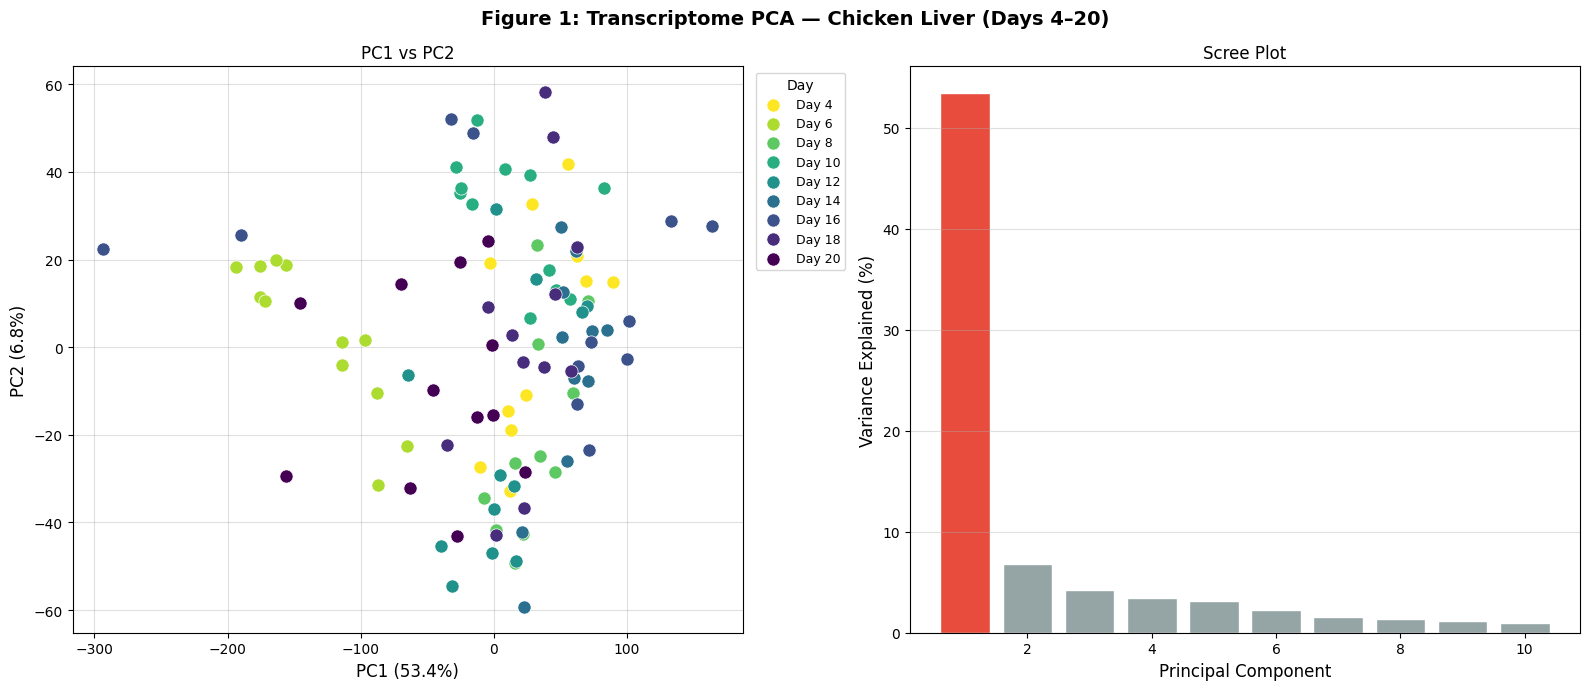

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Figure 1: Transcriptome PCA — Chicken Liver (Days 4–20)',
             fontsize=14, fontweight='bold')
ax = axes[0]
for day in DAYS:
  idx = np.where(sample_meta['Day'].values == day)[0]
  ax.scatter(Xpca[idx, 0], Xpca[idx, 1], c=DAY_COLORS[day], label=f'Day {day}',
              s=90, edgecolors='white', linewidth=0.5, zorder=3)
ax.set_xlabel(f'PC1 ({pca_t.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_t.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('PC1 vs PC2', fontsize=12)
ax.legend(title='Day', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.4)

ax2  = axes[1]
pct  = pca_t.explained_variance_ratio_ * 100
ax2.bar(range(1, 11), pct, color=['#e74c3c'] + ['#95a5a6']*9, edgecolor='white')
ax2.set_xlabel('Principal Component', fontsize=12)
ax2.set_ylabel('Variance Explained (%)', fontsize=12)
ax2.set_title('Scree Plot', fontsize=12)
ax2.grid(True, alpha=0.4, axis='y')

plt.tight_layout()


(15,)

## New dataframe with values average over days

In [ ]:
# First make a dictionary with col name corresponding to days
groups = {}
for col in df.columns[3:]:
  day = col.split("_")[-1]
  # If day not in dict, intializes, otherwise append col to that list
  groups.setdefault(day, []).append(col)
print(len(groups["4"]), groups["4"])

df_days = pd.DataFrame()

11 ['1650_summed_TPM_4', '1651_summed_TPM_4', '1653_summed_TPM_4', '1654_summed_TPM_4', '1655_summed_TPM_4', '1656_summed_TPM_4', '1657_summed_TPM_4', '1671_summed_TPM_4', '1672_summed_TPM_4', '1673_summed_TPM_4', '1776_summed_TPM_4']


In [ ]:
# Add gene symbols as first column
df_days = pd.DataFrame({df.columns[0]: df.iloc[:,0]})

# Find the mean and variance for days
for day, cols in groups.items():
  df_days[f"day{day}_avg"] = df[cols].mean(axis=1)
  df_days[f"day{day}_sigma"] = df[cols].var(axis=1)
df_days

,Gene Symbol,day4_avg,day4_sigma,day6_avg,day6_sigma,day8_avg,day8_sigma,day10_avg,day10_sigma,day12_avg,day12_sigma,day14_avg,day14_sigma,day16_avg,day16_sigma,day18_avg,day18_sigma,day20_avg,day20_sigma
0,ZZZ3,4.225709,2.517081,0.953764,0.236265,4.278279,2.169685,4.195737,3.731420,3.034347,1.728714,5.011790,0.892738,5.130389,9.468639,3.784953,1.347033,2.150913,1.377910
1,ZYX,36.047936,128.615525,19.705650,50.019128,29.822050,29.563380,30.575958,70.740881,29.802075,40.237388,30.175145,37.592915,32.275750,232.706551,25.898283,62.448888,27.205017,74.934826
2,ZXDC,2.607343,0.948288,0.777705,0.099151,2.712533,0.307017,2.360046,0.334795,2.362605,1.060999,2.876152,0.497583,2.983429,3.308391,2.311302,0.364755,1.841165,0.499996
3,ZW10,7.528290,5.357893,2.225634,0.790829,7.726521,2.562777,6.723687,4.861016,6.354158,6.124200,8.891599,3.149292,8.195503,21.528411,6.118378,2.442329,4.577793,3.223964
4,ZUFSP,2.978055,0.426497,1.061303,0.310436,4.806378,2.082001,3.969455,1.846055,3.463997,3.029641,5.564387,3.310879,5.995768,13.203438,5.555640,4.883451,2.157520,0.694160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14460,A4GALT,0.122044,0.006417,0.082118,0.001656,0.258182,0.009369,0.289407,0.027268,0.425451,0.016768,0.396496,0.014947,0.397687,0.056705,0.425251,0.048323,0.256623,0.032031
14461,A2ML4,551.419455,70636.710641,226.178283,13908.780751,594.449333,77057.541869,759.427500,56240.779358,513.685917,36339.196924,819.509727,64960.204381,1024.191250,560689.746632,720.742750,48419.017177,766.655750,93687.188298
14462,A2ML2,196.006000,2076.804730,77.918633,2032.221987,190.413658,2479.902551,207.086750,2906.735239,184.406167,3459.627833,297.231727,4893.783380,225.701117,13326.146568,298.123917,5467.390572,225.626392,9473.869084
14463,A1CF,68.160064,1235.826170,10.178156,6.156964,39.292748,800.760427,82.992950,456.928781,37.565825,1060.531148,72.911318,557.412911,62.248866,829.201585,67.366875,1217.030397,33.796170,428.364901


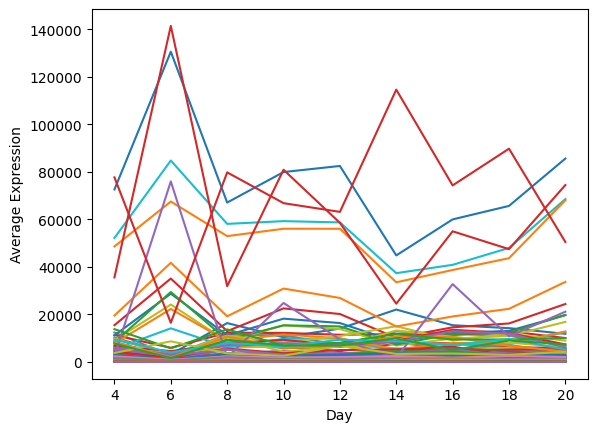

In [ ]:
import matplotlib.pyplot as plt

#iterating over the rows or essentially genes
for _, row in df_days.iterrows():
  x = []
  y = []
  for day, cols in groups.items():
    x.append(int(day))
    y.append(row[f"day{day}_avg"])
  plt.plot(x,y)
  plt.xlabel("Day")
  plt.ylabel("Average Expression")
  #plt.yscale('log')

In [ ]:
#col_new_names = [name.split('_')[0] +'_' +name.split('_')[3] for name in df.columns[1:]]
#col_new_names[:5]
#df.columns = list(df.columns[:1]) + col_new_names
#df

In [ ]:
chicken_tag = [tag_name.split('_')[0] for tag_name in df.columns[2:]]
list_days = list(set([int(day.split('_')[-1]) for day in df.columns[2:]]))

In [ ]:
list_days.sort()
list_days

[4, 6, 8, 10, 12, 14, 16, 18, 20]

In [ ]:
df_day4 = df.loc[:,["Gene Symbol"] + df.filter(regex=r"_4$").columns.tolist()]

In [ ]:
df_day4

,Gene Symbol,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,1672_summed_TPM_4,1673_summed_TPM_4,1776_summed_TPM_4
0,ZZZ3,2.148670,4.204060,3.609380,6.677230,3.849120,7.354150,5.040800,3.031530,2.721210,3.941250,3.905400
1,ZYX,24.366200,32.569200,31.253900,37.847200,37.692800,56.604800,33.385700,27.918300,34.052300,57.311000,23.525900
2,ZXDC,2.032480,2.471470,1.543100,3.037720,1.771860,4.079810,2.900180,2.161720,2.230180,4.596810,1.855440
3,ZW10,4.834760,7.150830,5.563670,10.117100,5.905610,12.052000,9.869820,6.426870,5.543910,8.634280,6.712340
4,ZUFSP,3.170700,2.908370,2.354820,3.346660,2.564770,3.133150,4.454180,3.496990,2.421560,2.140630,2.766770
...,...,...,...,...,...,...,...,...,...,...,...,...
14460,A4GALT,0.074452,0.156464,0.029587,0.139465,0.190539,0.308782,0.056601,0.067055,0.061017,0.105077,0.153445
14461,A2ML4,243.909000,340.262000,289.809000,584.728000,281.682000,509.980000,664.186000,492.456000,1092.230000,723.640000,842.732000
14462,A2ML2,247.332000,182.951000,172.501000,183.129000,118.826000,234.194000,283.293000,169.966000,165.030000,182.840000,216.004000
14463,A1CF,22.040600,55.038200,26.661900,96.158400,26.078800,69.539400,111.482000,104.168000,76.200500,114.381000,48.011900


In [ ]:
#df_day6 = df.loc[:,["Gene Symbol"] + df.filter(regex=r"_6$").columns.tolist()]
#df_day6

In [ ]:
#df